### This notebook we are going to create load data, split the data, feature scaling, CV folds , model creation and training. 


In [11]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer,SimpleImputer
from sklearn.metrics import roc_auc_score,accuracy_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import joblib
import time
import shap
import matplotlib.pyplot as plt
import lime.lime_tabular
import re

In [3]:
data = pd.read_parquet('C:\\Kuslu\\project\\Credit Scoring with XAI\\Data\\Processed\\application_train_processed.parquet')


### Spliting the Data into testing and trainig

In [4]:
X = data.drop('TARGET', axis=1)
Y = data['TARGET']
num_cols = [col for col in X.columns if X[col].dtype in ['int64', 'float64'] and X[col].nunique() > 2]

### Performing Label Encoding

In [5]:
# Encode each categorical column directly in X
object_cols = [col for col in X.columns if X[col].dtype == 'object']
label_encoders = {}
for col in object_cols:
    le = LabelEncoder()
    # Handle NaN values by filling with a placeholder before encoding
    X[col] = X[col].fillna('Missing')
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le  # Store encoder for later use

print("✅ Categorical encoding complete!")
print(f"\nData types after encoding:")
print(X.dtypes.value_counts())

✅ Categorical encoding complete!

Data types after encoding:
float64    68
int32      61
int64      46
bool       21
Int64       2
Name: count, dtype: int64


In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

### Imputing on numeric data 

In [7]:
micee_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = micee_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = micee_imputer.transform(X_test[num_cols])

### Feature Scaling

In [8]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
Scaler = StandardScaler()
X_train_scaled[num_cols] = Scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = Scaler.transform(X_test[num_cols])

### Performing CV folds

In [9]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Defining and Training the model

In [12]:
# --- STEP 1: Calculate Class Weights for Imbalance ---
# XGBoost/LGBM need a specific ratio number (Count Neg / Count Pos)
count_neg = Y_train.value_counts()[0]
count_pos = Y_train.value_counts()[1]
scale_pos_weight_value = count_neg / count_pos

# print(f"Imbalance Ratio (scale_pos_weight): {scale_pos_weight_value:.2f}")

# --- STEP 2: Define the Models ---
# We use a dictionary to store them for easy iteration
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', 
        solver='liblinear', 
        random_state=42,
        max_iter=1000  # Increased to ensure convergence
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,      # Keep reasonably low for speed
        max_depth=10,          # Limit depth to prevent overfitting & memory crashes
        class_weight='balanced',
        n_jobs=-1,             # Use all CPU cores
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale_pos_weight_value, # Handle Imbalance
        tree_method='hist',                      # Use 'hist' for CPU (fast) or 'gpu_hist' for GPU
        # For GPU: need to convert data to GPU format (cuDF/cuPy) to avoid warnings
        # device='cpu',  # Explicitly use CPU to avoid GPU warnings with pandas DataFrames
        eval_metric='auc',
        random_state=42
    ),
    
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        class_weight='balanced', # Handle Imbalance
        device='cpu',            # Use CPU (change to 'gpu' if you have GPU-enabled LightGBM)
        random_state=42,
        verbose=-1               # Silence warnings
    ),
    
    "CatBoost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=6,
        auto_class_weights='Balanced', # Handle Imbalance
        task_type="CPU",               # Use CPU (change to 'GPU' for GPU training)
        verbose=0,                     # Silence training output
        random_state=42
    )
}

# --- STEP 3: Training Loop ---
results = {}

print(f"\n{'Model':<20} | {'CV AUC Mean':<12} | {'Time (s)':<10}")
print("-" * 50)

for name, model in models.items():
    start_time = time.time()
    
    # 1. Choose the right data
    # Linear Models & RF get Scaled Data. Boosters get Unscaled (better performance).
    if name in ["Logistic Regression", "Random Forest"]:
        X_current = X_train_scaled # Ideally use X_train_scaled if you have it
        # NOTE: If your X_train is ALREADY scaled from previous step, just use X_train
    else:
        X_current = X_train   
    # 2. Perform Cross-Validation
    # This trains the model 5 times (once per fold)
    cv_scores = cross_val_score(
        model, 
        X_current, 
        Y_train, 
        cv=cv_strategy, 
        scoring='roc_auc', 
        n_jobs=1 # Set to 1 because GPU models handle parallelism internally
    )
    
    # 3. Fit on Full Training Set (for final usage)
    model.fit(X_current, Y_train)
    
    elapsed_time = time.time() - start_time
    mean_auc = cv_scores.mean()
    
    # Store results
    results[name] = {"model": model, "auc": mean_auc, "scores": cv_scores}
    
    print(f"{name:<20} | {mean_auc:.4f}       | {elapsed_time:.1f}s")

print("-" * 50)
print("Training Complete.")


Model                | CV AUC Mean  | Time (s)  
--------------------------------------------------
Logistic Regression  | 0.7469       | 567.9s
Random Forest        | 0.7283       | 61.4s
XGBoost              | 0.7536       | 30.6s
LightGBM             | 0.7556       | 24.4s
CatBoost             | 0.7528       | 47.7s
--------------------------------------------------
Training Complete.


### Saving the Best Model 

In [17]:
joblib.dump(results['LightGBM']['model'],'C:\Kuslu\project\Credit Scoring with XAI\Model\lightgbm_credit_model.pkl')
print('Best Model Saved')

Best Model Saved


### Explainability with Shap

<>:3: SyntaxWarning: invalid escape sequence '\K'
<>:3: SyntaxWarning: invalid escape sequence '\K'
C:\Users\rohit\AppData\Local\Temp\ipykernel_15244\2238857535.py:3: SyntaxWarning: invalid escape sequence '\K'
  model = joblib.load('C:\Kuslu\project\Credit Scoring with XAI\Model\lightgbm_credit_model.pkl')
c:\Kuslu\project\Credit Scoring with XAI\venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.2.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Kuslu\project\Credit Scoring with XAI\venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


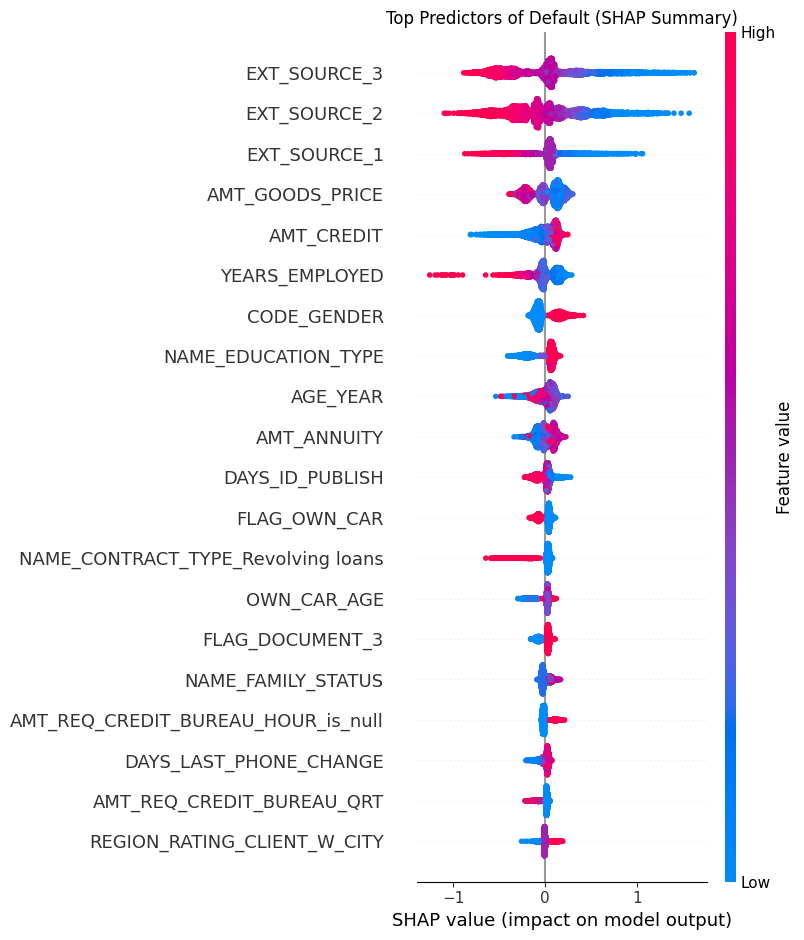

In [10]:
# 1. Select the Best Model
# model = results["LightGBM"]["model"]
model = joblib.load('C:\Kuslu\project\Credit Scoring with XAI\Model\lightgbm_credit_model.pkl')
# 2. Create the Explainer
# TreeExplainer is optimized for LightGBM/XGBoost
explainer = shap.TreeExplainer(model)

# 3. Calculate SHAP Values on a Sample (Speed Optimization)
# We take 5000 random samples from X_test to keep it fast
X_test_sample = X_test.sample(n=5000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# 4. Handle SHAP Output Format (LightGBM specific)
# LightGBM binary classification returns a list of 2 arrays (class 0 and class 1).
# We want the values for Class 1 (Default), which is index 1.
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# --- PLOT 1: The Global Summary ---
plt.figure(figsize=(10, 8))
plt.title("Top Predictors of Default (SHAP Summary)")
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.show()

### Explainability with lime

In [ ]:
# --- 1. Initialize LIME Explainer ---
# mode='classification' is essential
# explainer_lime = lime.lime_tabular.LimeTabularExplainer(
#     training_data=np.array(X_train),
#     feature_names=X_train.columns,
#     class_names=['Repaid', 'Default'],
#     mode='classification'
# )

# # --- 2. Pick the SAME Customer we analyzed with SHAP ---
# # We need the raw values for this specific row
# customer_data = X_test_sample.iloc[risky_customer_index]

# # --- 3. Generate Explanation ---
# # predict_fn requires the model's probability function
# exp = explainer_lime.explain_instance(
#     data_row=customer_data, 
#     predict_fn=model.predict_proba,
#     num_features=10
# )

# # --- 4. Visualize ---
# # Show in notebook
# exp.show_in_notebook(show_table=True)

# Optional: Save as HTML to share with stakeholders
# exp.save_to_file('lime_explanation.html')

NameError: name 'risky_customer_index' is not defined